# JM市场状态预测

## 分钟频次市场状态预测

# 1. 数据准备

## 1.1 观察数据

In [14]:
#导包
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.cluster import KMeans

In [15]:
df_min = pd.read_csv('../data/kline_im.csv')
df_min.set_index('DateTime', inplace=True)
df_min

,Unnamed: 0,day,open,high,low,close,vol,amount,twap,rsrs,...,max_ret_index,min_ret_index,max_amount_index,increase_kline_ratio,decrease_kline_ratio,equal_kline_ratio,vwap_ema_1,vwap_ema_2,pct,slippage
DateTime,,,,,,,,,,,,,,,,,,,,,
2022/7/22 9:30,0,2022/7/22,5041.799985,5076.999985,5032.799985,5047.599985,2597,3670919280,5062.106651,0.514591,...,1,13,0,0.533333,0.400000,0.066667,1.411248e+06,1.413470e+06,-0.011966,1.981140e-07
2022/7/22 9:45,1,2022/7/22,5048.199985,5048.599985,4976.799985,4987.199985,2292,3214320560,5001.066651,0.973886,...,7,2,5,0.200000,0.800000,0.000000,1.399274e+06,1.402205e+06,0.003930,2.005133e-07
2022/7/22 10:00,2,2022/7/22,4987.199985,5016.199985,4984.399985,5006.799985,1422,1994239360,5004.039985,0.818966,...,0,13,13,0.666667,0.266667,0.066667,1.403338e+06,1.402740e+06,0.006551,1.997284e-07
2022/7/22 10:15,3,2022/7/22,5008.199985,5045.599985,5000.799985,5039.599985,1392,1957681760,5022.933318,1.042818,...,10,0,11,0.666667,0.333333,0.000000,1.408995e+06,1.406698e+06,-0.003730,1.984284e-07
2022/7/22 10:30,4,2022/7/22,5039.399985,5039.599985,5016.799985,5020.799985,1118,1572904440,5025.826651,1.083749,...,3,2,11,0.333333,0.666667,0.000000,1.406104e+06,1.406730e+06,-0.005577,1.991714e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026/3/20 13:45,11,2026/3/20,7660.000000,7666.200000,7642.000000,7643.800000,5447,8336630920,7652.946667,1.085567,...,8,9,1,0.400000,0.600000,0.000000,1.529395e+06,1.530344e+06,-0.001465,1.308250e-07
2026/3/20 14:00,12,2026/3/20,7643.800000,7664.800000,7625.600000,7632.600000,6613,10109080200,7643.773333,1.033320,...,6,8,9,0.400000,0.533333,0.066667,1.526780e+06,1.528041e+06,-0.000524,1.310170e-07
2026/3/20 14:15,13,2026/3/20,7633.000000,7643.800000,7619.400000,7628.600000,5162,7878171720,7631.746667,0.822899,...,2,4,2,0.466667,0.533333,0.000000,1.525637e+06,1.526077e+06,-0.002779,1.310857e-07


## 1.2 特征工程

In [16]:
# 波动率特征
def get_dd(ret, hl):
    downside_ret = ret.copy()
    downside_ret[downside_ret > 0] = 0
    return np.sqrt((downside_ret**2).ewm(halflife=hl).mean())

In [17]:
# 收益率特征
df_min['return'] = np.log(df_min['close']) - np.log(df_min['close'].shift(1))
df_min['ewma_ret'] = df_min['return'].ewm(halflife=120).mean()
# 波动率特征
df_min['dd20'] = get_dd(df_min['return'], 20)
df_min['dd60'] = get_dd(df_min['return'], 60)
df_min['dd120'] = get_dd(df_min['return'], 120)
df_min['dd20_60'] = df_min['dd20'] - df_min['dd60']
df_min['dd60_120'] = df_min['dd60'] - df_min['dd120']
df_min['dd20_120'] = df_min['dd20'] - df_min['dd120']
df_min = df_min.drop(df_min.index[:1])
df_min.index = pd.to_datetime(df_min.index)
df_min.index

DatetimeIndex(['2022-07-22 09:45:00', '2022-07-22 10:00:00',
               '2022-07-22 10:15:00', '2022-07-22 10:30:00',
               '2022-07-22 10:45:00', '2022-07-22 11:00:00',
               '2022-07-22 11:15:00', '2022-07-22 13:00:00',
               '2022-07-22 13:15:00', '2022-07-22 13:30:00',
               ...
               '2026-03-20 11:00:00', '2026-03-20 11:15:00',
               '2026-03-20 13:00:00', '2026-03-20 13:15:00',
               '2026-03-20 13:30:00', '2026-03-20 13:45:00',
               '2026-03-20 14:00:00', '2026-03-20 14:15:00',
               '2026-03-20 14:30:00', '2026-03-20 14:45:00'],
              dtype='datetime64[ns]', name='DateTime', length=14178, freq=None)

In [18]:
# 一日对数成交量差
df_min['f1'] = np.log(df_min['vol']) - np.log(df_min['vol'].shift(1))

# 五日对数成交量差
df_min['f2'] = np.log(df_min['vol']) - np.log(df_min['vol'].shift(5))

# 一日对数收盘价差 (当日收益率)
df_min['return'] = np.log(df_min['close']) - np.log(df_min['close'].shift(1))

# 五日对数收盘价差 (五日动量)
df_min['f4'] = np.log(df_min['close']) - np.log(df_min['close'].shift(5))

# 当日对数高低价差 (当日内波动)
df_min['f5'] = np.log(df_min['high']) - np.log(df_min['low'])
# 删除前五行数据（滑窗）
df_min = df_min.drop(df_min.index[:5])
df_min.index = pd.to_datetime(df_min.index)
df_min

,Unnamed: 0,day,open,high,low,close,vol,amount,twap,rsrs,...,dd20,dd60,dd120,dd20_60,dd60_120,dd20_120,f1,f2,f4,f5
DateTime,,,,,,,,,,,,,,,,,,,,,
2022-07-22 11:00:00,6,2022/7/22,4994.199985,5006.599985,4986.199985,4988.399985,778,1089874960,4996.893318,0.847811,...,0.005486,0.005589,0.005615,-0.000103,-2.601192e-05,-0.000129,-0.269851,-1.080454,0.000241,0.004083
2022-07-22 11:15:00,7,2022/7/22,4986.399985,4986.399985,4915.999985,4931.999985,1399,1948265560,4956.306651,0.787778,...,0.006766,0.006763,0.006763,0.000003,-2.125005e-07,0.000003,0.586786,-0.016307,-0.015052,0.014219
2022-07-22 13:00:00,8,2022/7/22,4931.599985,4965.599985,4930.999985,4965.399985,1068,1486543960,4953.679985,0.760959,...,0.006272,0.006308,0.006317,-0.000035,-9.511060e-06,-0.000045,-0.269970,-0.264954,-0.014833,0.006992
2022-07-22 13:15:00,9,2022/7/22,4963.799985,4965.199985,4936.599985,4949.199985,717,998363960,4953.693318,0.788164,...,0.005975,0.006033,0.006048,-0.000058,-1.511734e-05,-0.000074,-0.398467,-0.444221,-0.014363,0.005777
2022-07-22 13:30:00,10,2022/7/22,4949.199985,4949.199985,4876.999985,4877.599985,2331,3221942640,4903.893318,1.055265,...,0.007500,0.007411,0.007391,0.000088,2.053587e-05,0.000109,1.178977,0.827476,-0.023344,0.014696
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-20 13:45:00,11,2026/3/20,7660.000000,7666.200000,7642.000000,7643.800000,5447,8336630920,7652.946667,1.085567,...,0.003536,0.003249,0.003124,0.000287,1.250583e-04,0.000412,0.074489,-0.393088,-0.008338,0.003162
2026-03-20 14:00:00,12,2026/3/20,7643.800000,7664.800000,7625.600000,7632.600000,6613,10109080200,7643.773333,1.033320,...,0.003486,0.003234,0.003117,0.000251,1.171879e-04,0.000369,0.193972,-0.676988,-0.016863,0.005127
2026-03-20 14:15:00,13,2026/3/20,7633.000000,7643.800000,7619.400000,7628.600000,5162,7878171720,7631.746667,0.822899,...,0.003427,0.003216,0.003108,0.000211,1.077861e-04,0.000319,-0.247713,-0.534450,-0.010769,0.003197


## 1.3 特征标准化

In [19]:
# 滚动窗口标准化
window = 336
features = ["f1", "f2", "return", "f4", "f5"]
# features = ["ewma_ret","dd20", "dd60", "dd120", "dd20_60", "dd60_120", "dd20_120"]
# 计算滚动均值和滚动标准差
rolling_mean = df_min[features].rolling(window=window).mean()
rolling_std = df_min[features].rolling(window=window).std()


# 执行滚动标准化
# 前 251 行会因为窗口不足产生 NaN
df_feature_rolling = (df_min[features] - rolling_mean) / rolling_std
df_train_norm = df_feature_rolling.loc[:'2024-09-30 15:00:00'].dropna()
df_test_norm = df_feature_rolling.loc['2024-10-01 09:30:00':]
X_train = df_train_norm
X_test = df_test_norm
X_train

,f1,f2,return,f4,f5
DateTime,,,,,
2022-08-22 10:45:00,-0.392599,-1.743519,0.495830,1.825330,-0.074224
2022-08-22 11:00:00,-0.490779,-1.527475,0.029064,0.510186,-0.474419
2022-08-22 11:15:00,1.084143,-0.531036,0.351455,0.973073,-0.294397
2022-08-22 13:00:00,-1.013599,-0.681060,-0.120642,0.544520,-0.607748
2022-08-22 13:15:00,-0.820340,-1.059490,0.169203,0.466102,-0.690475
...,...,...,...,...,...
2024-09-30 13:45:00,-3.713275,-3.304020,-0.154572,1.041712,-1.201911
2024-09-30 14:00:00,-3.009369,-4.754675,-0.155117,0.297635,-1.199239
2024-09-30 14:15:00,6.839381,-0.734854,-0.154770,0.464132,-0.241714


In [20]:
# 过滤出原表（用于回测计算）
df_train_rolling = df_min.loc[df_train_norm.index]
df_test_rolling = df_min.loc[df_test_norm.index]
df_test_rolling

,Unnamed: 0,day,open,high,low,close,vol,amount,twap,rsrs,...,dd20,dd60,dd120,dd20_60,dd60_120,dd20_120,f1,f2,f4,f5
DateTime,,,,,,,,,,,,,,,,,,,,,
2024-10-08 09:30:00,8528,2024/10/8,5283.599998,5283.599998,5245.399998,5277.399998,13110,16614235520,5281.599998,-6.430000e-27,...,0.004317,0.003800,0.003410,0.000516,0.000390,0.000906,4.218440,3.268524,0.112897,0.007256
2024-10-08 09:45:00,8529,2024/10/8,5279.599998,5283.599998,5269.599998,5283.599998,2984,3781533480,5283.599998,7.234154e-26,...,0.004242,0.003778,0.003400,0.000464,0.000378,0.000842,-1.480111,3.436672,0.114071,0.002653
2024-10-08 10:00:00,8530,2024/10/8,5283.599998,5283.599998,5147.199998,5149.199998,11814,14874581080,5259.319998,5.484912e-01,...,0.006325,0.004662,0.003914,0.001662,0.000748,0.002411,1.376021,0.795184,0.088305,0.026155
2024-10-08 10:15:00,8531,2024/10/8,5145.999998,5283.199998,5129.199998,5136.799998,12898,16182979600,5225.306665,6.792863e-01,...,0.006232,0.004643,0.003907,0.001589,0.000736,0.002325,0.087787,3.931438,0.085894,0.029582
2024-10-08 10:30:00,8532,2024/10/8,5135.399998,5162.399998,4839.599998,5153.999998,17691,21536400280,5050.279998,6.650614e-01,...,0.006125,0.004616,0.003896,0.001509,0.000720,0.002229,0.315984,4.518121,0.089236,0.064570
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-20 13:45:00,11,2026/3/20,7660.000000,7666.200000,7642.000000,7643.800000,5447,8336630920,7652.946667,1.085567e+00,...,0.003536,0.003249,0.003124,0.000287,0.000125,0.000412,0.074489,-0.393088,-0.008338,0.003162
2026-03-20 14:00:00,12,2026/3/20,7643.800000,7664.800000,7625.600000,7632.600000,6613,10109080200,7643.773333,1.033320e+00,...,0.003486,0.003234,0.003117,0.000251,0.000117,0.000369,0.193972,-0.676988,-0.016863,0.005127
2026-03-20 14:15:00,13,2026/3/20,7633.000000,7643.800000,7619.400000,7628.600000,5162,7878171720,7631.746667,8.228993e-01,...,0.003427,0.003216,0.003108,0.000211,0.000108,0.000319,-0.247713,-0.534450,-0.010769,0.003197


# 2.模型算法

## 2.1 JM模型训练

In [21]:
# 迭代算法
def viterbi_jump(y, theta, lam):
    """
    动态规划部分：在固定 theta 的情况下寻找最优路径 s
    y: (T, D) 特征矩阵
    theta: (K, D) 状态中心
    lam: 跳跃惩罚系数
    """
    T = len(y) # 时间步数
    K = len(theta) # 状态数量
    
    # V[t, k] 记录到时刻 t 停在状态 k 的最小代价
    V = np.zeros((T, K))
    # B[t, k] 记录回溯最优状态
    B = np.zeros((T, K), dtype=int)
    
    # 初始化 t=0
    for k in range(K):
        # 距离
        V[0, k] = np.sum((y[0] - theta[k])**2)
        
    # 正向递推
    for t in range(1, T):
        for k in range(K):
            # 拟合损失
            loss_t_k = np.sum((y[t] - theta[k])**2)
            
            # 从各状态转移过来的总代价
            costs = []
            for j in range(K):
                penalty = 0 if j == k else lam
                costs.append(V[t-1, j] + penalty)
            
            best_prev_state = np.argmin(costs)
            V[t, k] = loss_t_k + costs[best_prev_state]
            B[t, k] = best_prev_state
            
    # 反向回溯
    states = np.zeros(T, dtype=int)
    states[-1] = np.argmin(V[-1, :]) # 在最后一天选出损失最小的状态
    for t in range(T-2, -1, -1):
        states[t] = B[t+1, states[t+1]]
        
    return states, V

def fit_sjm(y, K, lam, max_iter):
    """
    坐标下降法训练 SJM
    """
    T, D = y.shape
    # 随机初始化状态中心 (可以用 KMeans 初始化)
    kmeans = KMeans(n_clusters=K).fit(y)
    theta = kmeans.cluster_centers_
    
    states = np.zeros(T, dtype=int)
    V_new = np.zeros((T, K))
    count = 0
    for i in range(max_iter):
        old_states = states.copy()
        
        # Step A: 固定 theta, 优化状态序列 s (动态规划)
        states, V = viterbi_jump(y, theta, lam)
        
        # Step B: 固定 states, 优化 theta (取均值)
        for k in range(K):
            theta[k] = np.mean(y[states == k], axis=0) # bool掩码索引
        count += 1
        # 检查收敛性
        if np.array_equal(old_states, states):
            V_new = V
            print("最大迭代次数：", count)
            break
        # 更新状态
        V_new = V
    print("最大迭代次数：", count)
    return states, theta, V_new

# 测试集推理代码
def predict_test_set(y_test, theta, lam, states, V_grid):
    """
    y_test: 测试集特征 (T_test, D)
    theta: 训练好的状态中心 (K, D)
    lam: 训练时选定的最优惩罚项
    states: 训练集的最优状态序列
    V_grid: 训练集的动态规划代价矩阵
    """
    T_test = len(y_test)
    K = len(theta)
    
    test_states = np.zeros(T_test, dtype=int)
    
    # 记录前一天的累积代价（训练集中最后一天的结果）
    v_prev = V_grid[-1, :]
    v_prev[states[-1]] = 0
    
    for t in range(T_test):
        v_current = np.zeros(K)

        for k in range(K):
            # 计算今天如果选状态 k 的拟合损失
            dist_sq = np.sum((y_test[t] - theta[k])**2)
            
            # 考虑从昨天所有可能状态 j 转移过来的代价
            costs = []
            for j in range(K):
                penalty = 0 if j == k else lam
                costs.append(v_prev[j] + penalty)
            
            # 选出最省钱的来路
            v_current[k] = dist_sq + min(costs)
            
        # 确定今天的状态（取令 v_current 最小的 k）
        test_states[t] = np.argmin(v_current)
        
        # 更新 v_prev 进入下一天
        v_prev = v_current
        
    return test_states

In [22]:
# 模型训练+拟合
train_states, theta, V_grid = fit_sjm(X_train.values, K=3, lam=20.0, max_iter=1000)
test_states = predict_test_set(X_test.values, theta, 10.0, train_states, V_grid)
print("train_states:", train_states[:100])
print("theta:", theta)
print("V_grid:", V_grid)
print("test_states:", test_states[100:200])

df_train_plot = df_train_rolling.copy() 
df_test_plot = df_test_rolling.copy()   
df_train_plot['state'] = train_states
df_test_plot['state'] = test_states
df_train_plot

最大迭代次数： 5
最大迭代次数： 5
train_states: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
theta: [[ 0.05449375  0.45994546  1.23705566  2.27467253  1.6081336 ]
 [-0.00812586 -0.04323748 -0.01366891 -0.01809894 -0.13131066]
 [ 0.05965086  0.24098806 -0.67375373 -1.40480853  1.34303479]]
V_grid: [[8.63679840e+00 6.69985282e+00 1.79531395e+01]
 [2.17936462e+01 9.53440362e+00 2.88478706e+01]
 [2.99339423e+01 1.21077367e+01 3.98800331e+01]
 ...
 [4.16107514e+04 4.15822833e+04 4.16078427e+04]
 [4.16602964e+04 4.16207358e+04 4.16502636e+04]
 [4.16702333e+04 0.00000000e+00 4.16602232e+04]]
test_states: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0
 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


,Unnamed: 0,day,open,high,low,close,vol,amount,twap,rsrs,...,dd60,dd120,dd20_60,dd60_120,dd20_120,f1,f2,f4,f5,state
DateTime,,,,,,,,,,,,,,,,,,,,,
2022-08-22 10:45:00,341,2022/8/22,5246.999986,5265.399986,5234.799986,5260.999986,1411,2034444120,5251.039986,9.454425e-01,...,0.002843,0.003191,0.000125,-0.000348,-0.000222,-0.180430,-1.234061,0.018803,0.005828,1
2022-08-22 11:00:00,342,2022/8/22,5260.599986,5263.799986,5240.799986,5262.599986,1126,1623491840,5249.426652,1.200473e+00,...,0.002827,0.003180,0.000091,-0.000354,-0.000263,-0.225627,-1.080389,0.005755,0.004379,1
2022-08-22 11:15:00,343,2022/8/22,5262.799986,5280.599986,5254.199986,5272.799986,1859,2687627680,5268.759986,1.032409e+00,...,0.002810,0.003170,0.000057,-0.000360,-0.000302,0.501367,-0.372843,0.010409,0.005012,1
2022-08-22 13:00:00,344,2022/8/22,5270.199986,5275.399986,5254.999986,5270.599986,1164,1681564480,5265.439986,8.173226e-01,...,0.002794,0.003159,0.000025,-0.000365,-0.000340,-0.468176,-0.480473,0.006204,0.003875,1
2022-08-22 13:15:00,345,2022/8/22,5268.399986,5277.799986,5258.999986,5275.999986,797,1152291480,5270.106652,9.429847e-01,...,0.002777,0.003149,-0.000007,-0.000371,-0.000378,-0.378763,-0.751629,0.005474,0.003568,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-30 13:45:00,8523,2024/9/30,4713.999998,4713.999998,4713.999998,4713.999998,499,575806080,4713.999998,1.000000e+00,...,0.003911,0.003460,0.000796,0.000452,0.001248,-2.001047,-2.880863,0.023785,0.000000,1
2024-09-30 14:00:00,8524,2024/9/30,4713.999998,4713.999998,4713.999998,4713.999998,96,110776320,4713.999998,1.000000e+00,...,0.003889,0.003450,0.000737,0.000439,0.001177,-1.648258,-4.307999,0.010578,0.000000,1
2024-09-30 14:15:00,8525,2024/9/30,4713.999998,4713.999998,4683.799998,4713.999998,5334,6147341040,4710.746665,3.707575e-28,...,0.003867,0.003440,0.000680,0.000427,0.001107,4.017509,-0.673648,0.013584,0.006427,1


# 3.回测可视化

## 3.1 训练集状态分类情况

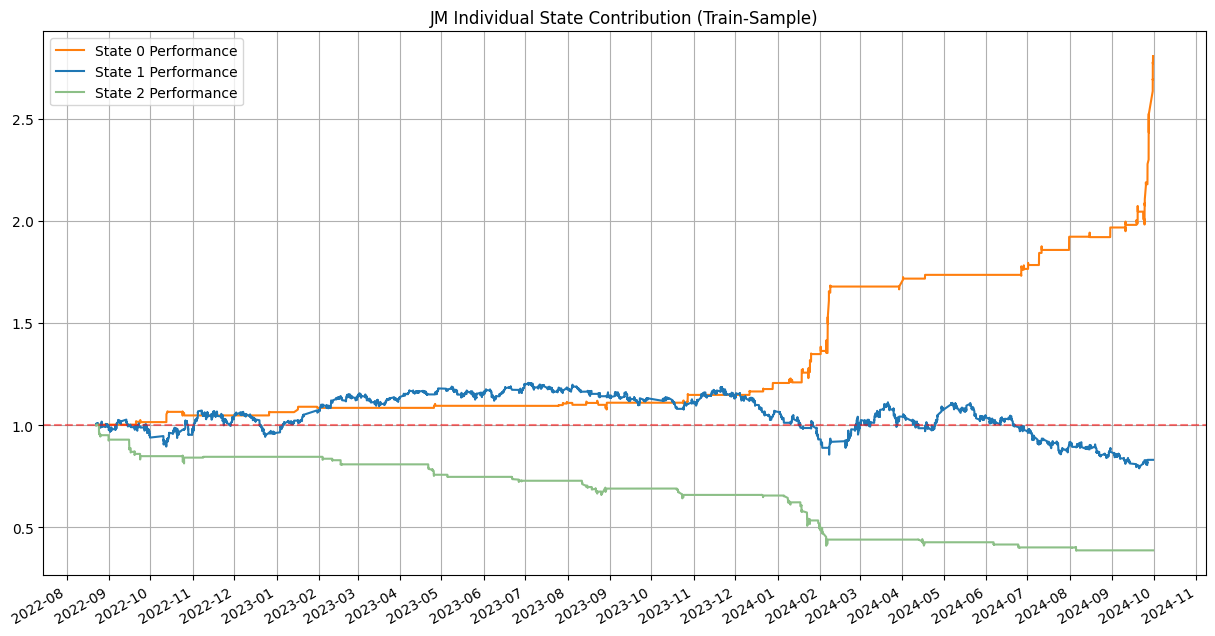

In [23]:
colors = ['#ff7f0e', '#1f77b4', "#8CBF87", "#8D2F25", "#909291", "#4E1945", "#B7B7Eb"]
plt.figure(figsize=(15, 8))
for i in range(len(V_grid[0])):
    df_train_sample = df_train_plot.copy()
    df_train_sample['signal'] = (df_train_plot['state'] == i).shift(1).fillna(0).astype(float)

    # 计算策略收益序列
    return_vals = df_train_sample['return'].astype(float).values
    signal = df_train_sample['signal'].astype(float).values
    strat_ret = return_vals * signal
    # 强制第一行跟随市场，确保起跑线逻辑一致
    strat_ret[0] = return_vals[0]
    
    # 净值为 1.0 的起点
    # 在所有收益率前面插一个 0
    strategy_cum = np.exp(np.insert(np.cumsum(strat_ret), 0, 0))
    # 插入数据后对应时间也要增加一列
    time_delta = df_train_sample.index[1] - df_train_sample.index[0] # 计算时间间隔
    plot_dates = [df_train_sample.index[0] - time_delta] + list(df_train_sample.index) #增加第一个时间
    plt.plot(plot_dates, strategy_cum, color=colors[i], label=f'State {i} Performance')

plt.axhline(1, color='red', linestyle='--', alpha=0.5) #基准线
plt.title("JM Individual State Contribution (Train-Sample)")
plt.legend()
plt.grid(True)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gcf().autofmt_xdate()
plt.show()

## 3.2 测试集状态分类情况

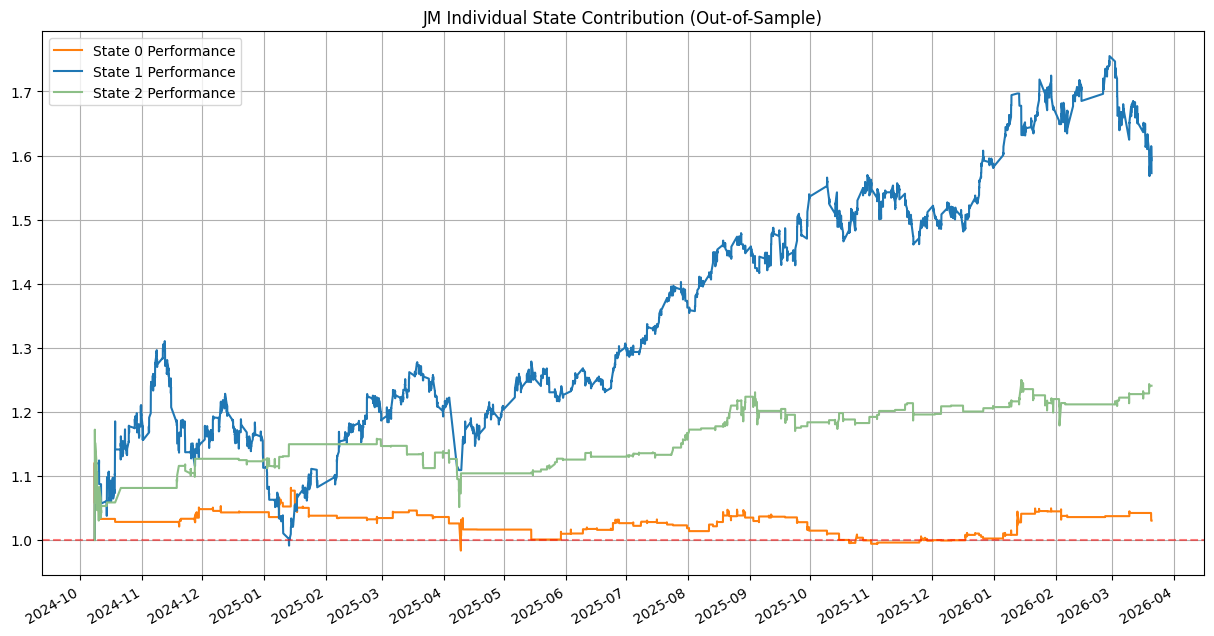

In [24]:
colors = ['#ff7f0e', '#1f77b4', "#8CBF87", "#8D2F25", "#909291", "#4E1945", "#B7B7Eb"]
plt.figure(figsize=(15, 8))
for i in range(len(V_grid[0])):
    df_test_sample = df_test_plot.copy()
    df_test_sample['signal'] = (df_test_plot['state'] == i).shift(1).fillna(0).astype(float)

    # 计算策略收益序列
    return_vals = df_test_sample['return'].astype(float).values
    signal = df_test_sample['signal'].astype(float).values
    strat_ret = return_vals * signal
    # 强制第一行跟随市场，确保起跑线逻辑一致
    strat_ret[0] = return_vals[0]
    
    # 净值为 1.0 的起点
    # 在所有收益率前面插一个 0
    strategy_cum = np.exp(np.insert(np.cumsum(strat_ret), 0, 0))
    # 插入数据后对应时间也要增加一列
    time_delta = df_test_sample.index[1] - df_test_sample.index[0] # 计算时间间隔
    plot_dates = [df_test_sample.index[0] - time_delta] + list(df_test_sample.index) #增加第一个时间
    plt.plot(plot_dates, strategy_cum, color=colors[i], label=f'State {i} Performance')

plt.axhline(1, color='red', linestyle='--', alpha=0.5) #基准线
plt.title("JM Individual State Contribution (Out-of-Sample)")
plt.legend()
plt.grid(True)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gcf().autofmt_xdate()
plt.show()

## 3.3 收益回测评估

In [25]:
# 计算最大回撤
def calculate_mdd(cum_series):
    """
    计算净值曲线的最大回撤及其结束时间点
    """
    # 转换为 numpy 数组方便计算
    nav = np.array(cum_series)
    # 计算历史滚动最高点
    peaks = np.maximum.accumulate(nav)
    # 计算回撤序列 (当前值 / 历史最高值 - 1)
    drawdowns = (nav - peaks) / peaks
    # 找到最大回撤值（最小值）
    mdd_value = np.min(drawdowns)
    # 找到最大回撤发生的索引位置（即回撤结束/最低点的位置）
    mdd_idx = np.argmin(drawdowns)
    
    return mdd_value, mdd_idx

【市场基准】最大回撤: -51.57% | 发生时间: 2024-02-05 10:45:00
【HMM策略】最大回撤: -34.65% | 发生时间: 2024-09-20 13:45:00


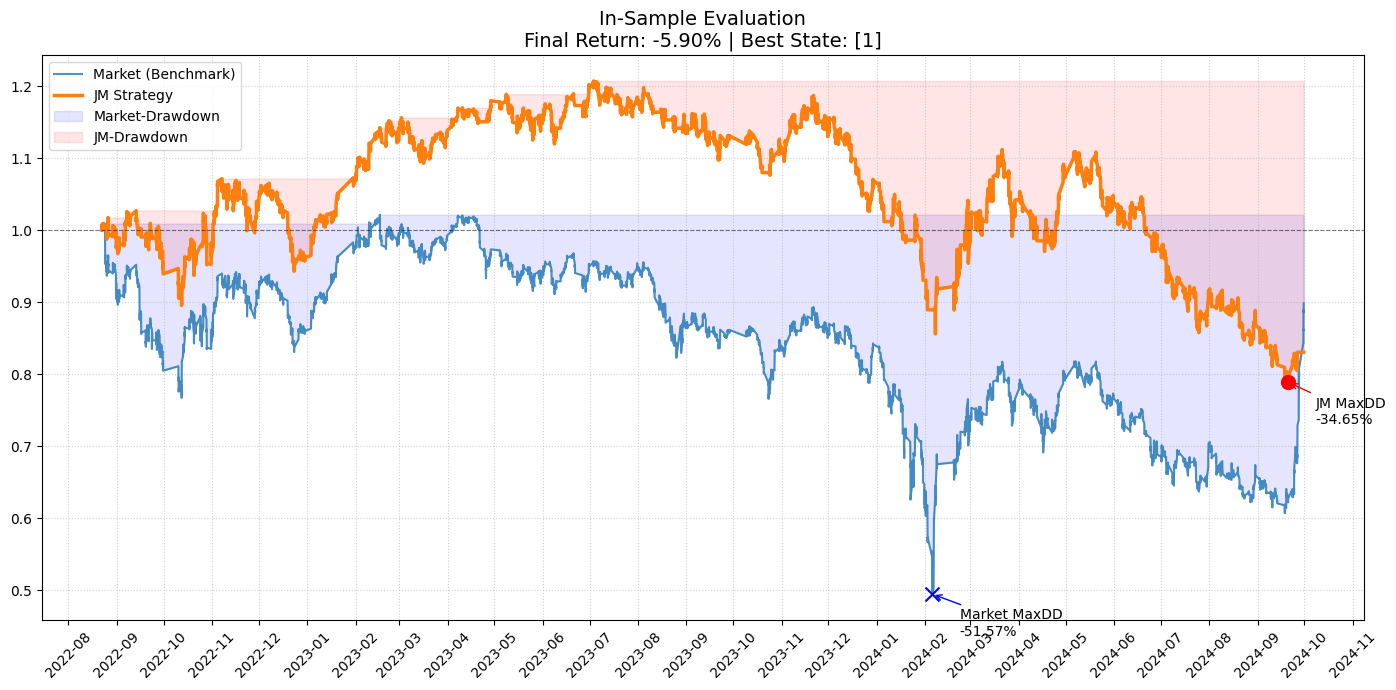

【市场基准】最大回撤: -22.65% | 发生时间: 2025-04-09 09:30:00
【HMM策略】最大回撤: -24.36% | 发生时间: 2025-01-13 13:00:00


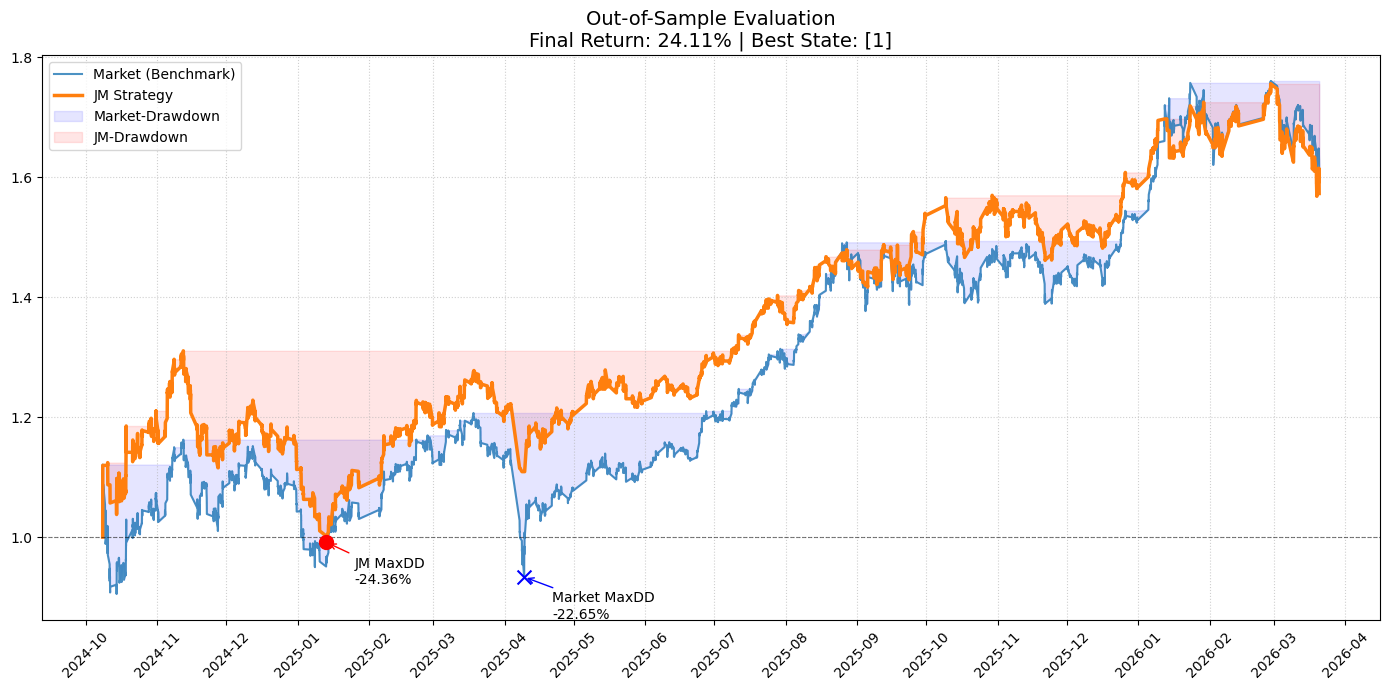

In [26]:
def plot_backtest(df_input, title, use_state):
    # 1. 深拷贝并预处理，确保无警告
    df = df_input.copy()
    df.index = pd.to_datetime(df.index)
    
    # T-1 时刻的状态决定 T 时刻的仓位
    # 这里后续可以考虑分不同权重
    signal = df['state'].isin(use_state).shift(1).fillna(0).astype(float) # state
    
    # 计算策略收益序列
    return_vals = df['return'].astype(float).values
    strat_ret = return_vals * signal.values
    
    # 强制第一行跟随市场，确保起跑线逻辑一致
    strat_ret[0] = return_vals[0]
    
    # 净值为 1.0 的起点
    # 在所有收益率前面插一个 0
    market_cum = np.exp(np.insert(np.cumsum(return_vals), 0, 0))
    strategy_cum = np.exp(np.insert(np.cumsum(strat_ret), 0, 0))
    # 插入数据后对应时间也要增加一列
    time_delta = df.index[1] - df.index[0] # 计算时间间隔
    plot_dates = [df.index[0] - time_delta] + list(df.index) #增加第一个时间
    # 计算年化收益率 (Annualized Return)
    total_days = (df.index[-1] - df.index[0]).total_seconds() / (24 * 3600)# 持有天数 (分钟数据，直接用总时长)
    # 策略最终净值
    final_nav = strategy_cum[-1]
    # 年化公式: (最终净值 ^ (252 / 实际天数)) - 1
    annual_ret = ((final_nav ** (252 / total_days)) - 1) * 100

    m_mdd_val, m_mdd_idx = calculate_mdd(market_cum)
    s_mdd_val, s_mdd_idx = calculate_mdd(strategy_cum)

    # 获取对应的日期（从 plot_dates 中提取）
    m_mdd_date = plot_dates[m_mdd_idx]
    s_mdd_date = plot_dates[s_mdd_idx]

    print(f"【市场基准】最大回撤: {m_mdd_val:.2%} | 发生时间: {m_mdd_date}")
    print(f"【HMM策略】最大回撤: {s_mdd_val:.2%} | 发生时间: {s_mdd_date}")

    plt.figure(figsize=(14, 7), dpi=100)
    
    # 使用你指定的蓝色和橙色
    plt.plot(plot_dates, market_cum, color='#1f77b4', label='Market (Benchmark)', alpha=0.8)
    plt.plot(plot_dates, strategy_cum, color='#ff7f0e', label='JM Strategy', linewidth=2.5)
    
    # 绘制最大回撤区域（可选，更专业）
    market_peak = np.maximum.accumulate(market_cum)
    strategy_peak = np.maximum.accumulate(strategy_cum)
    plt.fill_between(plot_dates, market_cum, market_peak, color='blue', alpha=0.1, label='Market-Drawdown')
    plt.fill_between(plot_dates, strategy_cum, strategy_peak, color='red', alpha=0.1, label='JM-Drawdown')

    # 起始点辅助线
    plt.axhline(1, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    
    # 标题与统计信息
    plt.title(f"{title}\nFinal Return: {annual_ret:.2f}% | Best State: {use_state}", fontsize=14)
    
    # 坐标轴优化
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper left')
    
    plt.tight_layout()
    plt.scatter(m_mdd_date, market_cum[m_mdd_idx], color='blue', s=100, marker='x', 
            label=f'Market MaxDD: {m_mdd_val:.2%}', zorder=5)

    # 标记策略最大回撤点
    plt.scatter(s_mdd_date, strategy_cum[s_mdd_idx], color='red', s=100, marker='o', 
                label=f'JM MaxDD: {s_mdd_val:.2%}', zorder=5)
    plt.annotate(f'Market MaxDD\n{m_mdd_val:.2%}', 
                xy=(m_mdd_date, market_cum[m_mdd_idx]), 
                xytext=(20, -30), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color='blue'))
    plt.annotate(f'JM MaxDD\n{s_mdd_val:.2%}', 
                xy=(s_mdd_date, strategy_cum[s_mdd_idx]), 
                xytext=(20, -30), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color='red'))
    plt.show()
# 状态总数
states = len(V_grid[0])
# 训练集确定best_state
# best_state = df_train_plot.groupby('state')['f3'].mean().idxmax()
buy_state = [1]
plot_backtest(df_train_plot, "In-Sample Evaluation", buy_state)
plot_backtest(df_test_plot, "Out-of-Sample Evaluation", buy_state)